<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Drinking_Water_Violation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

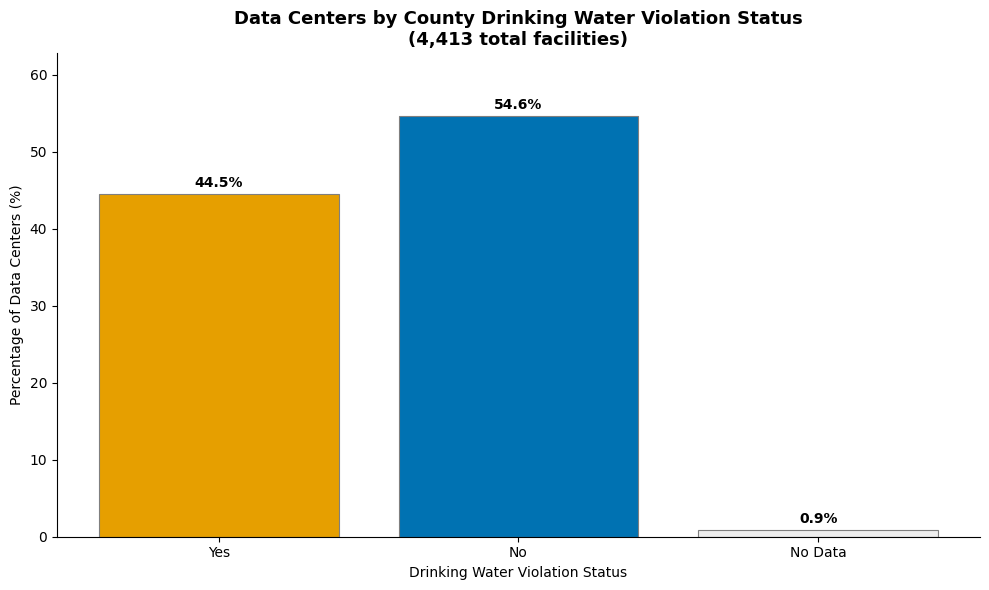

In [2]:
# Run once
# !pip install numpy pandas matplotlib openpyxl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Load & clean county-level drinking water data ----
file = "/content/2025 County Health Rankings Data - v4.xlsx"

excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

drinking_water = excel_data[[
    "FIPS",
    "State",
    "County",
    "Presence of Water Violation"
]].copy()

# Keep only county rows
drinking_water = drinking_water[drinking_water["County"].notna()].copy()

# Make FIPS match county shapefile GEOID
drinking_water["FIPS"] = (
    drinking_water["FIPS"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Clean violation values so they become Yes / No
raw_vals = drinking_water["Presence of Water Violation"]
numeric_vals = pd.to_numeric(raw_vals, errors="coerce")

drinking_water["water_violation_clean"] = pd.Series(index=drinking_water.index, dtype="object")

# Handle numeric values
drinking_water.loc[numeric_vals == 1, "water_violation_clean"] = "Yes"
drinking_water.loc[numeric_vals == 0, "water_violation_clean"] = "No"

# Handle text values
text_vals = raw_vals.astype(str).str.strip().str.lower()

drinking_water.loc[
    drinking_water["water_violation_clean"].isna() & text_vals.isin(["yes", "y", "true", "1.0"]),
    "water_violation_clean"
] = "Yes"

drinking_water.loc[
    drinking_water["water_violation_clean"].isna() & text_vals.isin(["no", "n", "false", "0.0"]),
    "water_violation_clean"
] = "No"

# ---- Load data center / facility locations ----
facilities_file = "/content/facilities_final_complete.xlsx"

facilities = pd.read_excel(
    facilities_file,
    sheet_name="facilities_final_complete"
)

# Clean fips the same way as the county data so they can be matched
facilities["fips"] = facilities["fips"].astype(int).astype(str).str.zfill(5)

total_facility_count = len(facilities)

# ---- Match each facility to its county's water violation status ----
facility_status = facilities.merge(
    drinking_water[["FIPS", "water_violation_clean"]],
    left_on="fips",
    right_on="FIPS",
    how="left"
)

# Violation status colors (same as the map legend)
yes_color = "#E69F00"      # orange
no_color = "#0072B2"       # blue
missing_color = "#eeeeee"  # light gray

# Count data centers in each status
yes_count = (facility_status["water_violation_clean"] == "Yes").sum()
no_count = (facility_status["water_violation_clean"] == "No").sum()
no_data_count = facility_status["water_violation_clean"].isna().sum()

labels = ["Yes", "No", "No Data"]
values = [yes_count, no_count, no_data_count]
colors = [yes_color, no_color, missing_color]

# Convert counts to a percentage of all facilities
percentages = [v / total_facility_count * 100 for v in values]

# ---- Plot ----
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    labels,
    percentages,
    color=colors,
    edgecolor="#7f7f7f",
    linewidth=0.8
)

# Percentage label above each bar
for bar, pct in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(percentages) * 0.01,
        f"{pct:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_title(
    f"Data Centers by County Drinking Water Violation Status\n({total_facility_count:,} total facilities)",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Drinking Water Violation Status")
ax.set_ylabel("Percentage of Data Centers (%)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, max(percentages) * 1.15)

plt.tight_layout()
plt.show()